<a href="https://colab.research.google.com/github/mardemes/energia_sin/blob/main/ENIAC_Energia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Este notebook apresenta uma anális dos dados de carga de energia elétrica diária disponibilizados pelo Operador Nacional do Sistema Elétrico (ONS), abrangendo o período de 2020 até meados de 2026. O objetivo é identificar padrões, tendências e sazonalidades no consumo de energia, além de realizar o tratamento dos dados para apoiar a construção de modelos de previsão.

**Fonte**: https://dados.ons.org.br/dataset/carga-energia

#EDA

## Principais Insights Identificados no EDA

## Qualidade dos Dados

### Célula 10 — Verificação de Datas Faltantes

Não foram identificadas datas faltantes na série agregada do SIN.

Isso indica que a série temporal é contínua ao longo de todo o período analisado, eliminando a necessidade de técnicas de imputação ou preenchimento de lacunas.

---

## Tendência da Série

### Células 13, 14 e 15 — Série Temporal e Médias Móveis

As médias móveis de 30 e 90 dias evidenciam uma tendência de crescimento gradual da carga elétrica ao longo dos anos.

A suavização da série permite observar que o aumento da demanda não ocorre apenas em períodos específicos, mas acompanha uma evolução consistente ao longo do tempo.

---

### Células 16 e 17 — Evolução Anual da Carga

Observou-se crescimento contínuo da carga média diária do SIN:

| Ano | Carga Média (MWmed) |
|------|------:|
| 2020 | ~63.408 |
| 2021 | ~68.525 |
| 2022 | ~68.797 |
| 2023 | ~73.704 |
| 2024 | ~78.943 |
| 2025 | ~79.608 |
| 2026 | ~81.554 |

Esse comportamento evidencia uma forte tendência de longo prazo na série.

---

## Comportamento dos Subsistemas

### Células 18 e 19 — Evolução e Distribuição por Subsistema

Todos os subsistemas apresentam comportamento semelhante ao longo do tempo.

Foi observado que:

- Sudeste/Centro-Oeste concentra os maiores valores de carga.
- Norte e Sul apresentam níveis menores de consumo.
- O comportamento geral das regiões sugere influência de fatores nacionais sobre a demanda energética.

---

### Célula 26 — Correlação Entre Subsistemas

Os subsistemas apresentam alta correlação entre si.

Isso indica que eventos econômicos, climáticos e sociais tendem a impactar simultaneamente diferentes regiões do país.

---

## Sazonalidade

### Células 21 e 22 — Sazonalidade Mensal

Foram identificados padrões recorrentes ao longo dos meses e anos.

A demanda energética apresenta comportamento sazonal, sugerindo influência de:

- Temperatura
- Clima
- Atividade econômica
- Calendário anual

---

### Células 23, 24 e 25 — Padrão Semanal

A média de carga por dia da semana foi:

| Dia | Média (MWmed) |
|------|------:|
| Segunda | 73.940 |
| Terça | 75.576 |
| Quarta | 75.753 |
| Quinta | 75.667 |
| Sexta | 75.127 |
| Sábado | 69.529 |
| Domingo | 64.040 |

Existe um padrão semanal muito forte.

A carga diminui significativamente nos finais de semana, especialmente aos domingos, refletindo a redução das atividades industriais e comerciais.

---

## Outliers

### Células 28, 29 e 30

Foram identificados apenas **6 outliers** em toda a série.

Os principais períodos foram:

- Abril de 2020
- Maio de 2020
- Fevereiro de 2025

Os outliers de abril e maio de 2020 coincidem com o período inicial da pandemia de COVID-19.

Portanto, esses pontos provavelmente representam eventos reais e não erros nos dados.

---

## Decomposição Temporal

### Célula 27 — STL

A decomposição STL evidenciou:

- Tendência crescente
- Sazonalidade recorrente
- Resíduos relativamente pequenos

A série possui estrutura temporal clara e não se comporta como um processo aleatório.

---

## Estacionariedade

### Célula 31 — Teste ADF na Série Original

Resultado:

- p-value > 0,05

A série original não é estacionária.

Isso já era esperado devido à presença de tendência e sazonalidade.

---

### Células 32, 33 e 34 — Série Diferenciada

Após aplicar a primeira diferença:

\[
y_t - y_{t-1}
\]

Resultado:

- p-value << 0,05

A série diferenciada tornou-se estacionária.

Isso demonstra que a tendência é uma das principais responsáveis pela não estacionariedade observada.

---

## Autocorrelação

### Célula 35 — ACF (60 lags)

Foi identificada forte dependência temporal entre observações próximas.

Além disso, observam-se picos recorrentes em:

- Lag 7
- Lag 14
- Lag 21
- Lag 28
- Lag 35
- Lag 42
- Lag 49
- Lag 56

Esses picos evidenciam um ciclo semanal extremamente forte.

---

### Células 36, 38 e 39 — ACF e PACF

As análises confirmam que a série possui memória temporal significativa.

A carga observada em determinado dia é fortemente influenciada pelos valores observados nos dias anteriores.

---

# Conclusão Geral

A série de carga elétrica do SIN apresenta:

- ✅ Tendência crescente de longo prazo
- ✅ Forte sazonalidade semanal
- ✅ Evidências de sazonalidade anual
- ✅ Alta dependência temporal
- ✅ Poucos outliers
- ✅ Série original não estacionária
- ✅ Série diferenciada estacionária

Esses resultados indicam que modelos capazes de capturar tendência e sazonalidade, como **SARIMA**, **Prophet** ou modelos de **Machine Learning com variáveis temporais**, possuem grande potencial para previsão da carga elétrica do SIN.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

In [ ]:
arquivos = sorted(Path(".").glob("CARGA_ENERGIA_*.parquet"))

print("Arquivos encontrados:")
for arquivo in arquivos:
    print(arquivo)

dfs = [pd.read_parquet(arq) for arq in arquivos]

df = pd.concat(dfs, ignore_index=True)

df.head()

Arquivos encontrados:
CARGA_ENERGIA_2020.parquet
CARGA_ENERGIA_2021.parquet
CARGA_ENERGIA_2022.parquet
CARGA_ENERGIA_2023.parquet
CARGA_ENERGIA_2024.parquet
CARGA_ENERGIA_2025.parquet
CARGA_ENERGIA_2026.parquet


,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed
0,N,Norte,2020-01-01,4851.26620833
1,NE,Nordeste,2020-01-01,9118.71941667
2,S,Sul,2020-01-01,9969.99487500
3,SE,Sudeste/Centro-Oeste,2020-01-01,33195.12464583
4,N,Norte,2020-01-02,5213.67437500


In [ ]:
# Converte a coluna de data para o formato datetime
df["din_instante"] = pd.to_datetime(df["din_instante"])

# Convertendo coluna de carga no formato numérico
df["val_cargaenergiamwmed"] = pd.to_numeric(
    df["val_cargaenergiamwmed"],
    errors="coerce"
)

df = df.sort_values("din_instante")

df.reset_index(drop=True, inplace=True)

df.head()

,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed
0,N,Norte,2020-01-01,4851.266208
1,NE,Nordeste,2020-01-01,9118.719417
2,S,Sul,2020-01-01,9969.994875
3,SE,Sudeste/Centro-Oeste,2020-01-01,33195.124646
4,N,Norte,2020-01-02,5213.674375


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9412 entries, 0 to 9411
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_subsistema          9412 non-null   object        
 1   nom_subsistema         9412 non-null   object        
 2   din_instante           9412 non-null   datetime64[ns]
 3   val_cargaenergiamwmed  9412 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 294.3+ KB


In [ ]:
df.describe(include="all")

,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed
count,9412,9412,9412,9412.000000
unique,4,4,NaN,NaN
top,N,Norte,NaN,NaN
freq,2353,2353,NaN,NaN
mean,NaN,NaN,2023-03-22 00:00:00,18201.581869
min,NaN,NaN,2020-01-01 00:00:00,4669.553958
25%,NaN,NaN,2021-08-11 00:00:00,8877.392372
50%,NaN,NaN,2023-03-22 00:00:00,12219.423792
75%,NaN,NaN,2024-10-30 00:00:00,21176.485198
max,NaN,NaN,2026-06-10 00:00:00,55584.896708


In [ ]:
print("Início:", df["din_instante"].min())
print("Fim:", df["din_instante"].max())
print("Total de registros:", len(df))
print("Quantidade de subsistemas:", df["nom_subsistema"].nunique())
print("Subsistemas:", df["nom_subsistema"].unique())

Início: 2020-01-01 00:00:00
Fim: 2026-06-10 00:00:00
Total de registros: 9412
Quantidade de subsistemas: 4
Subsistemas: ['Norte' 'Nordeste' 'Sul' 'Sudeste/Centro-Oeste']


In [ ]:
df.isna().sum()

,0
id_subsistema,0
nom_subsistema,0
din_instante,0
val_cargaenergiamwmed,0


In [ ]:
dias_por_subsistema = (
    df.groupby("nom_subsistema")["din_instante"]
      .nunique()
      .sort_values(ascending=False)
)

dias_por_subsistema

,din_instante
nom_subsistema,
Nordeste,2353
Norte,2353
Sudeste/Centro-Oeste,2353
Sul,2353


In [ ]:
# SÉRIE AGREGADA DO SIN
# soma a carga dos subsistemas por dia..

sin = (
    df.groupby("din_instante")["val_cargaenergiamwmed"]
      .sum()
      .reset_index()
)

sin.head()

,din_instante,val_cargaenergiamwmed
0,2020-01-01,57135.105146
1,2020-01-02,65163.694208
2,2020-01-03,65150.402708
3,2020-01-04,61463.301375
4,2020-01-05,57634.677208


In [ ]:
# VERIFICAÇÃO DE DATAS FALTANTES NA SÉRIE AGREGADA

datas_esperadas = pd.date_range(
    start=sin["din_instante"].min(),
    end=sin["din_instante"].max(),
    freq="D"
)

datas_faltantes = datas_esperadas.difference(
    sin["din_instante"]
)

print("Quantidade de datas faltantes:", len(datas_faltantes))

datas_faltantes

Quantidade de datas faltantes: 0


DatetimeIndex([], dtype='datetime64[ns]', freq='D')

In [ ]:
# DEFINIÇÃO DA FREQUÊNCIA DIÁRIA

sin_ts = sin.set_index("din_instante").asfreq("D")

sin_ts.head()

,val_cargaenergiamwmed
din_instante,
2020-01-01,57135.105146
2020-01-02,65163.694208
2020-01-03,65150.402708
2020-01-04,61463.301375
2020-01-05,57634.677208


In [ ]:
# ESTATÍSTICAS DA SÉRIE AGREGADA

sin["val_cargaenergiamwmed"].describe()

,val_cargaenergiamwmed
count,2353.000000
mean,72806.327476
std,8708.959713
min,48600.939875
25%,67175.159583
50%,72723.325458
75%,78633.973333
max,95880.764458


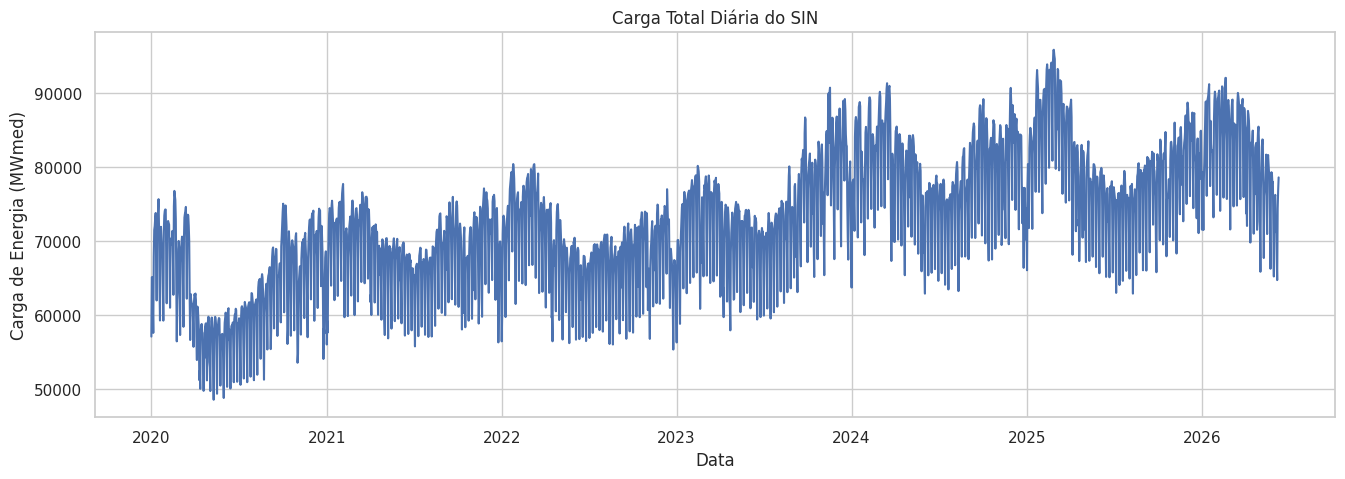

In [ ]:
# CÉLULA 13 - SÉRIE TEMPORAL PRINCIPAL

plt.figure(figsize=(16,5))

plt.plot(
    sin["din_instante"],
    sin["val_cargaenergiamwmed"]
)

plt.title("Carga Total Diária do SIN")
plt.xlabel("Data")
plt.ylabel("Carga de Energia (MWmed)")

plt.show()

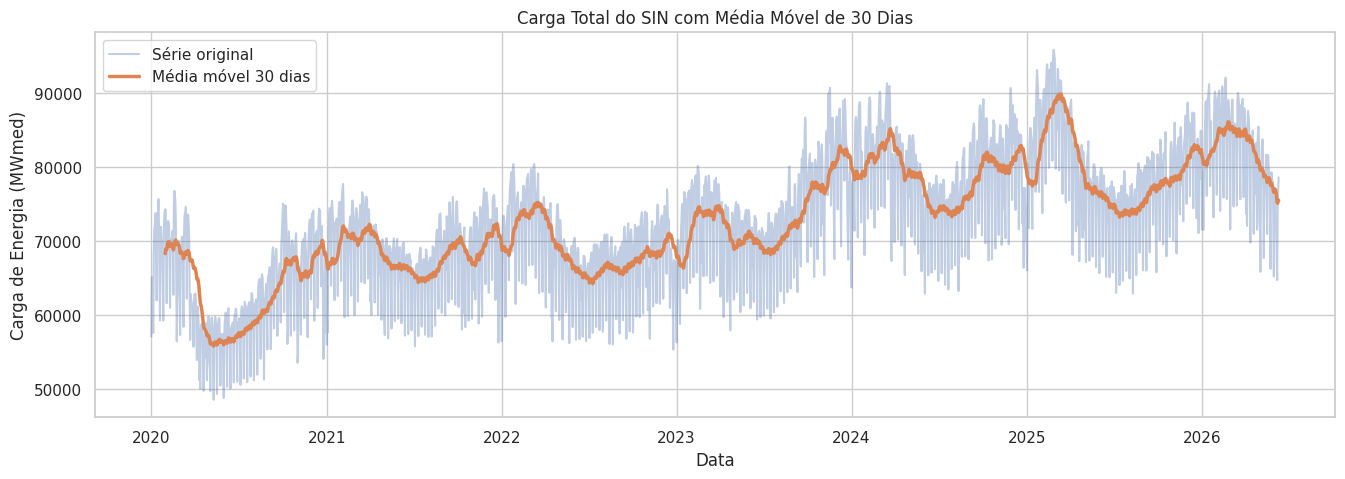

In [ ]:
# CÉLULA 14 - MÉDIA MÓVEL DE 30 DIAS

sin["ma30"] = (
    sin["val_cargaenergiamwmed"]
    .rolling(window=30)
    .mean()
)

plt.figure(figsize=(16,5))

plt.plot(
    sin["din_instante"],
    sin["val_cargaenergiamwmed"],
    alpha=0.35,
    label="Série original"
)

plt.plot(
    sin["din_instante"],
    sin["ma30"],
    linewidth=2.5,
    label="Média móvel 30 dias"
)

plt.title("Carga Total do SIN com Média Móvel de 30 Dias")
plt.xlabel("Data")
plt.ylabel("Carga de Energia (MWmed)")
plt.legend()

plt.show()

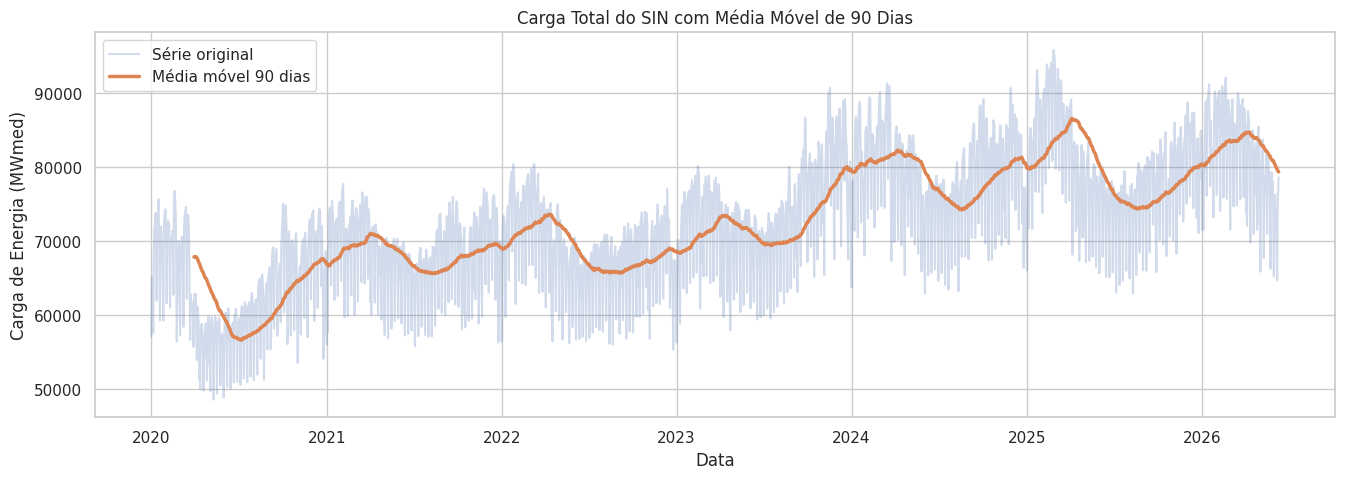

In [ ]:
# CÉLULA 15 - MÉDIA MÓVEL DE 90 DIAS

sin["ma90"] = (
    sin["val_cargaenergiamwmed"]
    .rolling(window=90)
    .mean()
)

plt.figure(figsize=(16,5))

plt.plot(
    sin["din_instante"],
    sin["val_cargaenergiamwmed"],
    alpha=0.25,
    label="Série original"
)

plt.plot(
    sin["din_instante"],
    sin["ma90"],
    linewidth=2.5,
    label="Média móvel 90 dias"
)

plt.title("Carga Total do SIN com Média Móvel de 90 Dias")
plt.xlabel("Data")
plt.ylabel("Carga de Energia (MWmed)")
plt.legend()

plt.show()

In [ ]:
# CÉLULA 16 - ANÁLISE ANUAL DA CARGA

sin["ano"] = sin["din_instante"].dt.year

media_anual = (
    sin.groupby("ano")["val_cargaenergiamwmed"]
       .mean()
       .reset_index()
)

media_anual

,ano,val_cargaenergiamwmed
0,2020,63408.467401
1,2021,68525.437025
2,2022,68797.198894
3,2023,73704.993205
4,2024,78943.251851
5,2025,79608.906773
6,2026,81554.184492


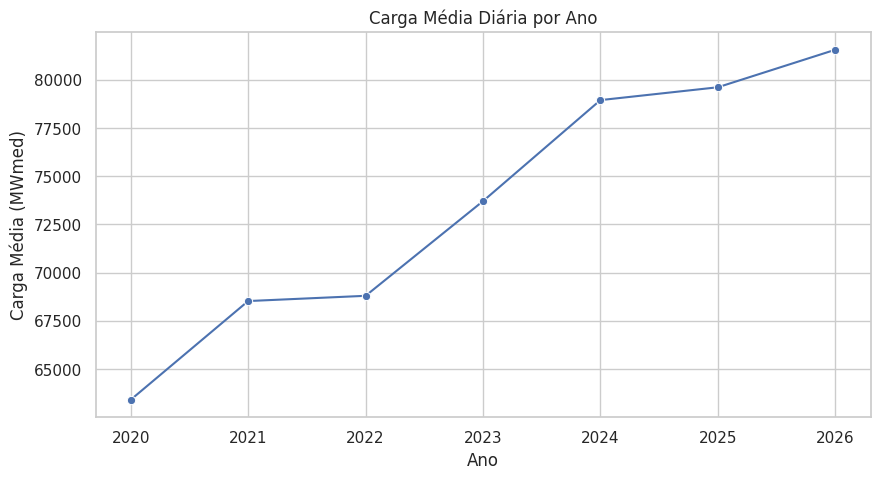

In [ ]:
# CÉLULA 17 - GRÁFICO DA MÉDIA ANUAL

plt.figure(figsize=(10,5))

sns.lineplot(
    data=media_anual,
    x="ano",
    y="val_cargaenergiamwmed",
    marker="o"
)

plt.title("Carga Média Diária por Ano")
plt.xlabel("Ano")
plt.ylabel("Carga Média (MWmed)")

plt.show()

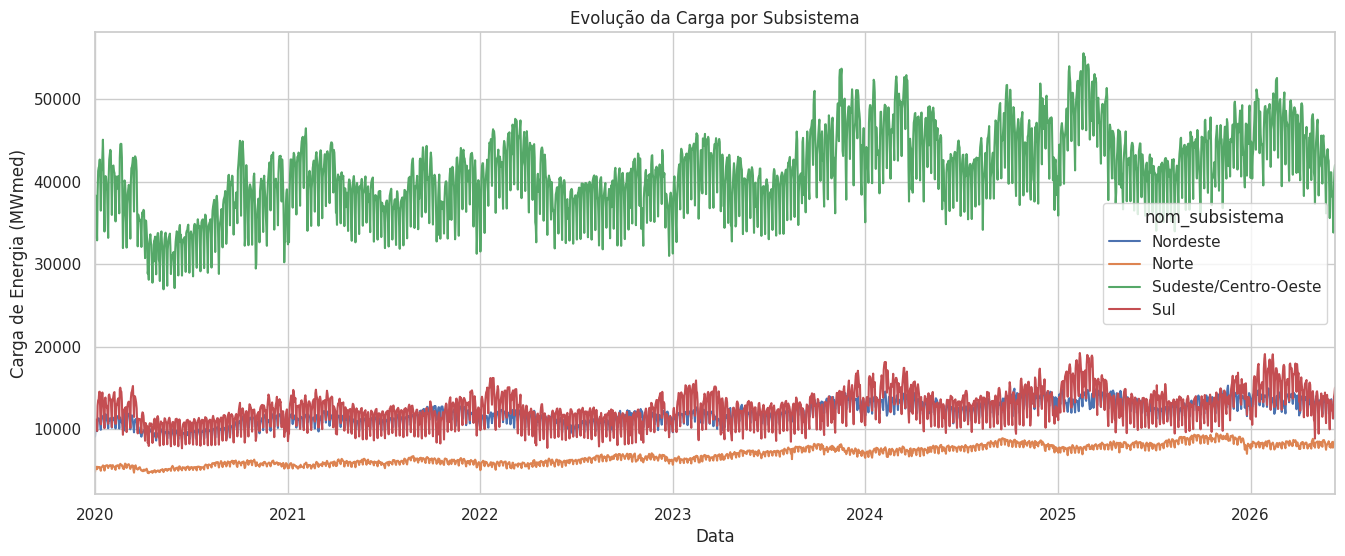

In [ ]:
# CÉLULA 18 - EVOLUÇÃO POR SUBSISTEMA
# permite comparar o comportamento regional da carga de energia.

pivot = df.pivot(
    index="din_instante",
    columns="nom_subsistema",
    values="val_cargaenergiamwmed"
)

pivot.plot(figsize=(16,6))

plt.title("Evolução da Carga por Subsistema")
plt.xlabel("Data")
plt.ylabel("Carga de Energia (MWmed)")

plt.show()

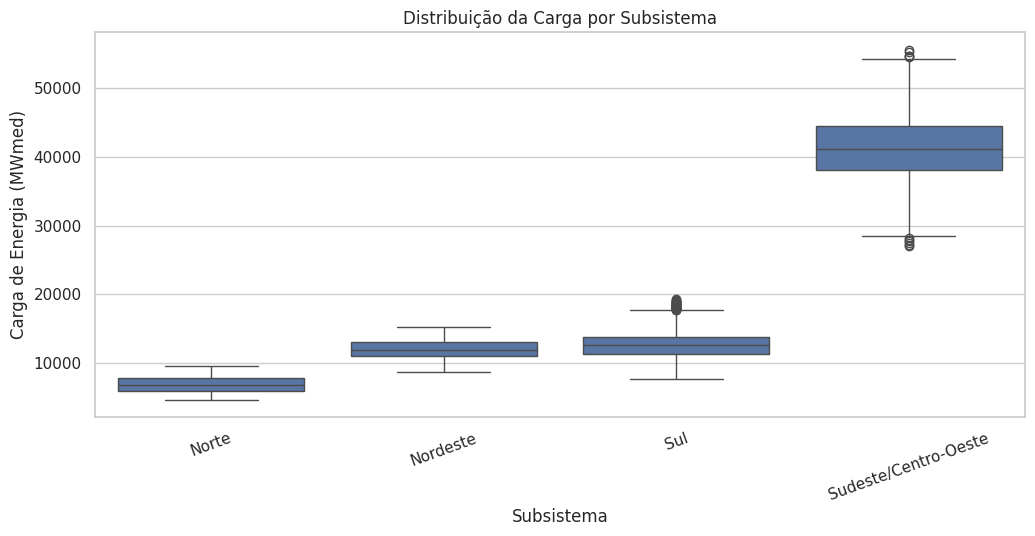

In [ ]:
# CÉLULA 19 - BOXPLOT POR SUBSISTEMA

plt.figure(figsize=(12,5))

sns.boxplot(
    data=df,
    x="nom_subsistema",
    y="val_cargaenergiamwmed"
)

plt.title("Distribuição da Carga por Subsistema")
plt.xlabel("Subsistema")
plt.ylabel("Carga de Energia (MWmed)")
plt.xticks(rotation=20)

plt.show()

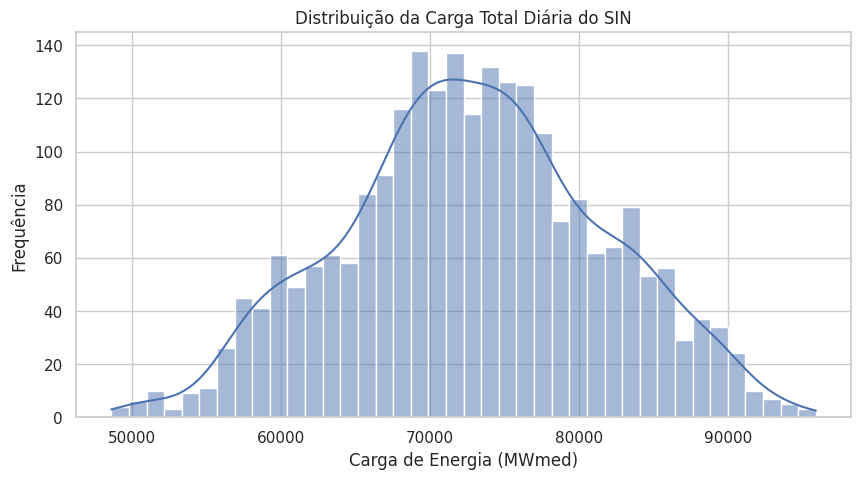

In [ ]:
# CÉLULA 20 - DISTRIBUIÇÃO DA CARGA TOTAL DO SIN

plt.figure(figsize=(10,5))

sns.histplot(
    sin["val_cargaenergiamwmed"],
    bins=40,
    kde=True
)

plt.title("Distribuição da Carga Total Diária do SIN")
plt.xlabel("Carga de Energia (MWmed)")
plt.ylabel("Frequência")

plt.show()

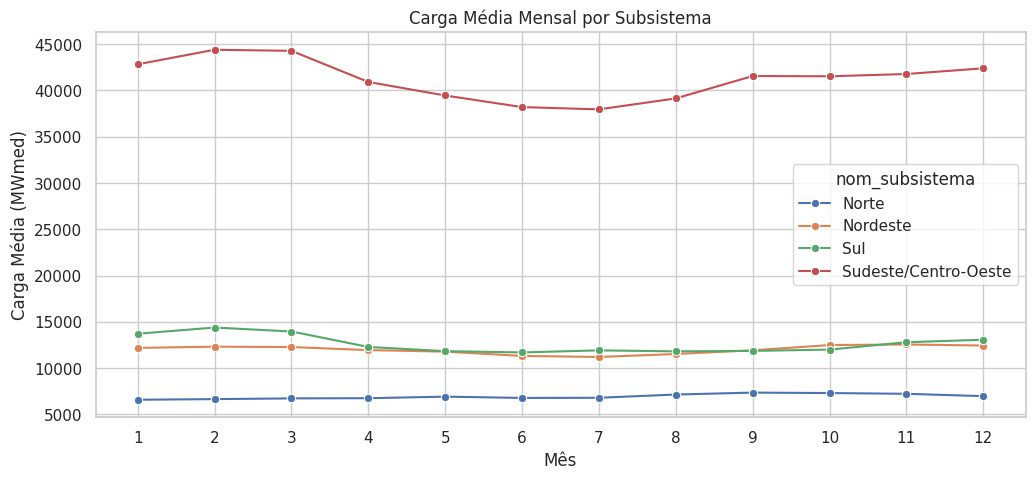

In [ ]:
# CÉLULA 21 - SAZONALIDADE MENSAL POR SUBSISTEMA

df["mes"] = df["din_instante"].dt.month

plt.figure(figsize=(12,5))

sns.lineplot(
    data=df,
    x="mes",
    y="val_cargaenergiamwmed",
    hue="nom_subsistema",
    estimator="mean",
    errorbar=None,
    marker="o"
)

plt.title("Carga Média Mensal por Subsistema")
plt.xlabel("Mês")
plt.ylabel("Carga Média (MWmed)")
plt.xticks(range(1, 13))

plt.show()

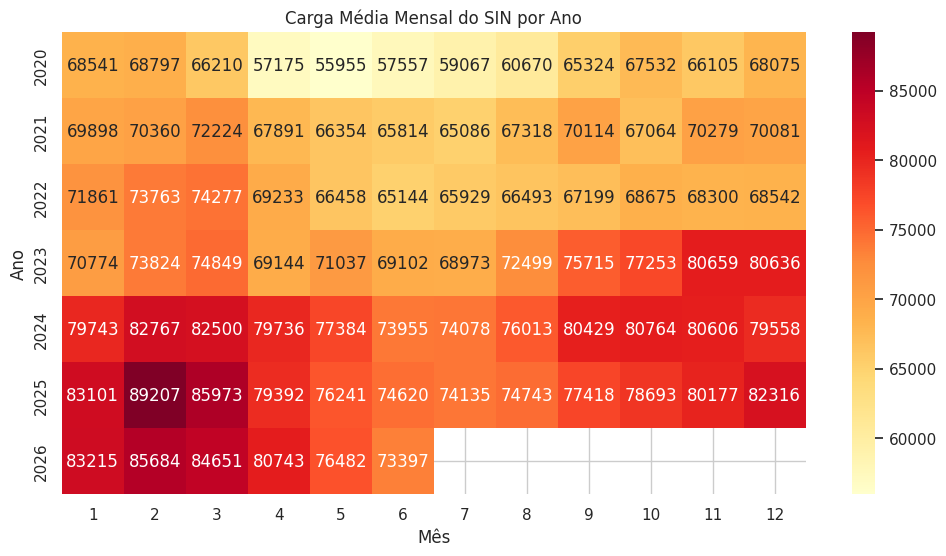

In [ ]:
# CÉLULA 22 - HEATMAP ANO X MÊS

sin["mes"] = sin["din_instante"].dt.month

heat = (
    sin.groupby(["ano", "mes"])["val_cargaenergiamwmed"]
       .mean()
       .unstack()
)

plt.figure(figsize=(12,6))

sns.heatmap(
    heat,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

plt.title("Carga Média Mensal do SIN por Ano")
plt.xlabel("Mês")
plt.ylabel("Ano")

plt.show()

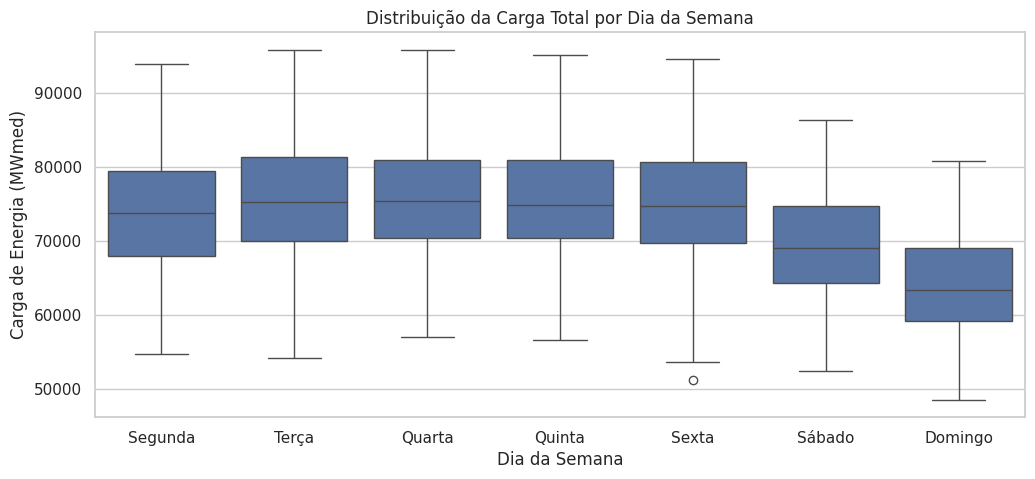

In [ ]:
# CÉLULA 23 - ANÁLISE POR DIA DA SEMANA

sin["dia_semana_num"] = sin["din_instante"].dt.dayofweek

mapa_dias = {
    0: "Segunda",
    1: "Terça",
    2: "Quarta",
    3: "Quinta",
    4: "Sexta",
    5: "Sábado",
    6: "Domingo"
}

sin["dia_semana"] = sin["dia_semana_num"].map(mapa_dias)

ordem_dias = [
    "Segunda",
    "Terça",
    "Quarta",
    "Quinta",
    "Sexta",
    "Sábado",
    "Domingo"
]

plt.figure(figsize=(12,5))

sns.boxplot(
    data=sin,
    x="dia_semana",
    y="val_cargaenergiamwmed",
    order=ordem_dias
)

plt.title("Distribuição da Carga Total por Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Carga de Energia (MWmed)")

plt.show()

In [ ]:
# CÉLULA 24 - MÉDIA POR DIA DA SEMANA

media_dia_semana = (
    sin.groupby("dia_semana")["val_cargaenergiamwmed"]
       .mean()
       .reindex(ordem_dias)
       .reset_index()
)

media_dia_semana

,dia_semana,val_cargaenergiamwmed
0,Segunda,73940.617890
1,Terça,75576.547284
2,Quarta,75753.701277
3,Quinta,75667.440848
4,Sexta,75127.064425
5,Sábado,69529.165942
6,Domingo,64040.982722


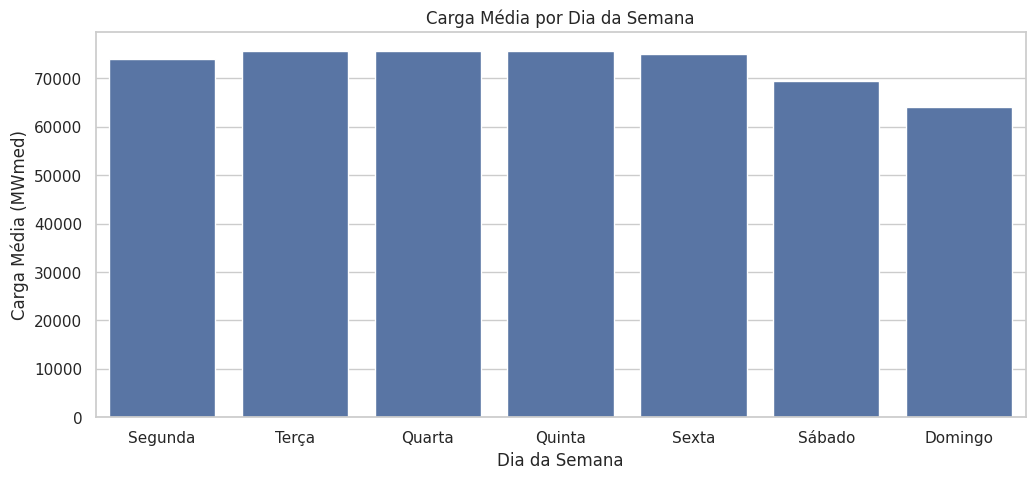

In [ ]:
# CÉLULA 25 - GRÁFICO DA MÉDIA POR DIA DA SEMANA

plt.figure(figsize=(12,5))

sns.barplot(
    data=media_dia_semana,
    x="dia_semana",
    y="val_cargaenergiamwmed",
    order=ordem_dias
)

plt.title("Carga Média por Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Carga Média (MWmed)")

plt.show()

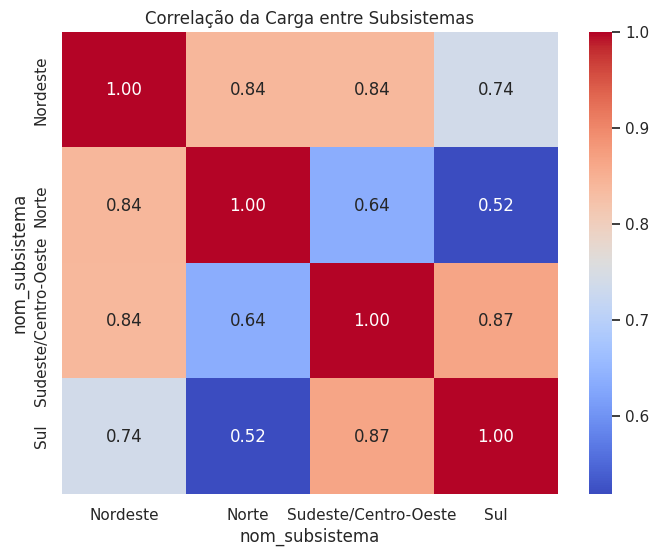

In [ ]:
# CÉLULA 26 - CORRELAÇÃO ENTRE SUBSISTEMAS

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlação da Carga entre Subsistemas")

plt.show()

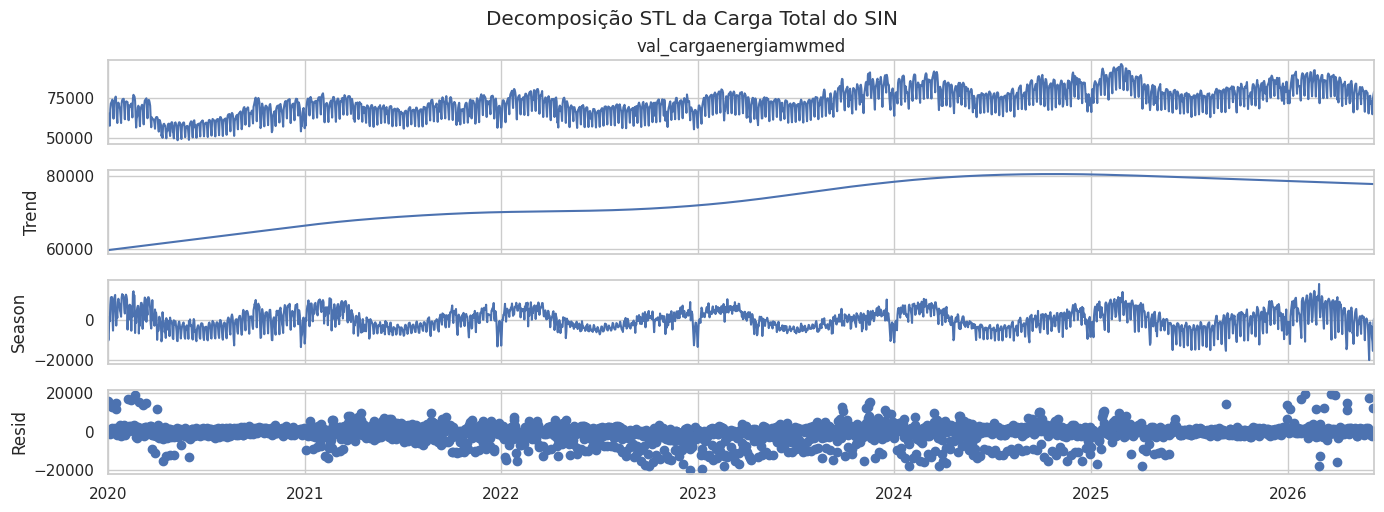

In [ ]:
# CÉLULA 27 - DECOMPOSIÇÃO STL DA SÉRIE

# 1. Tendência: movimento de longo prazo
# 2. Sazonalidade: padrões que se repetem
# 3. Resíduo: variações não explicadas pela tendência e sazonalidade


stl = STL(
    sin_ts["val_cargaenergiamwmed"],
    period=365,
    robust=True
)

resultado_stl = stl.fit()

resultado_stl.plot()

plt.suptitle("Decomposição STL da Carga Total do SIN", y=1.02)

plt.show()

In [ ]:
# CÉLULA 28 - IDENTIFICAÇÃO DE OUTLIERS

Q1 = sin["val_cargaenergiamwmed"].quantile(0.25)
Q3 = sin["val_cargaenergiamwmed"].quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = sin[
    (sin["val_cargaenergiamwmed"] < lim_inf) |
    (sin["val_cargaenergiamwmed"] > lim_sup)
].copy()

print("Limite inferior:", lim_inf)
print("Limite superior:", lim_sup)
print("Quantidade de outliers:", len(outliers))

outliers.head()

Limite inferior: 49986.938958315
Limite superior: 95822.193958355
Quantidade de outliers: 6


,din_instante,val_cargaenergiamwmed,ma30,ma90,ano,mes,dia_semana_num,dia_semana
109,2020-04-19,49803.770625,58494.708376,65609.478893,2020,4,6,Domingo
123,2020-05-03,49777.966333,56138.989115,63530.805353,2020,5,6,Domingo
130,2020-05-10,48600.939875,55860.753793,62484.757131,2020,5,6,Domingo
137,2020-05-17,49414.702500,56003.667904,61500.667031,2020,5,6,Domingo
151,2020-05-31,48841.676917,56030.501224,59754.339676,2020,5,6,Domingo


In [ ]:
# CÉLULA 29 - OUTLIERS POR ANO E MÊS

outliers["ano"] = outliers["din_instante"].dt.year
outliers["mes"] = outliers["din_instante"].dt.month

outliers_por_periodo = (
    outliers.groupby(["ano", "mes"])
            .size()
            .reset_index(name="quantidade_outliers")
)

outliers_por_periodo

,ano,mes,quantidade_outliers
0,2020,4,1
1,2020,5,4
2,2025,2,1


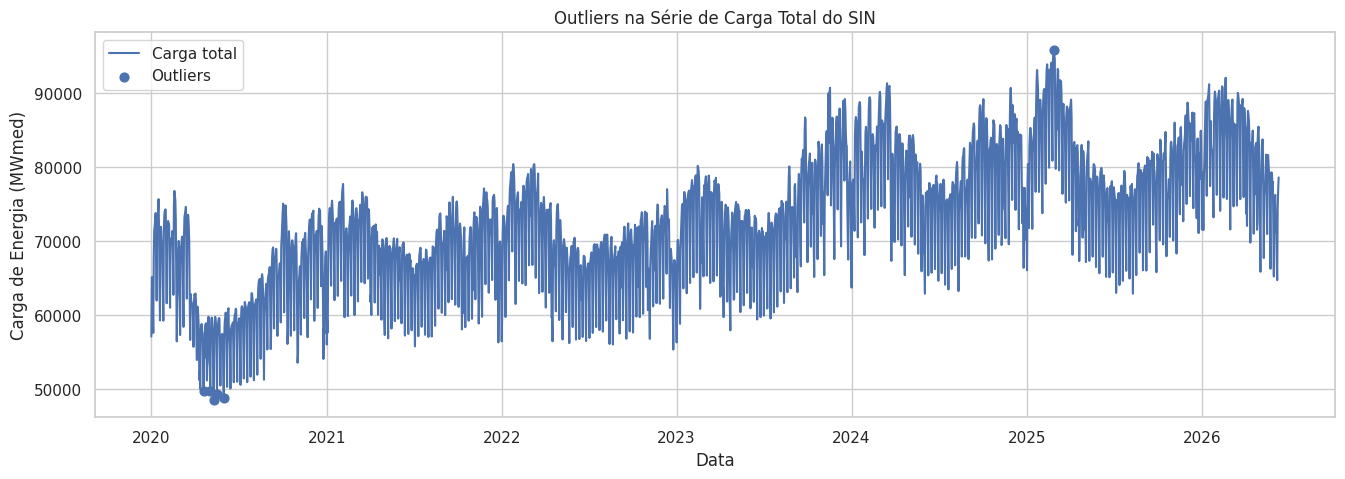

In [ ]:
# CÉLULA 30 - VISUALIZAÇÃO DOS OUTLIERS NA SÉRIE

plt.figure(figsize=(16,5))

plt.plot(
    sin["din_instante"],
    sin["val_cargaenergiamwmed"],
    label="Carga total"
)

plt.scatter(
    outliers["din_instante"],
    outliers["val_cargaenergiamwmed"],
    label="Outliers",
    s=40
)

plt.title("Outliers na Série de Carga Total do SIN")
plt.xlabel("Data")
plt.ylabel("Carga de Energia (MWmed)")
plt.legend()

plt.show()

In [ ]:
# CÉLULA 31 - TESTE ADF NA SÉRIE ORIGINAL

# Hipóteses do teste:
# H0: a série não é estacionária
# H1: a série é estacionária

# Se p-value < 0.05, rejeitamos H0 e consideramos a série estacionária.
# Se p-value >= 0.05, não rejeitamos H0 e consideramos que a série não é estacionária.

resultado_adf = adfuller(
    sin["val_cargaenergiamwmed"]
)

print("ADF:", resultado_adf[0])
print("p-value:", resultado_adf[1])

if resultado_adf[1] < 0.05:
    print("Interpretação: a série original pode ser considerada estacionária.")
else:
    print("Interpretação: a série original não é estacionária.")

ADF: -2.0625996388188605
p-value: 0.2598168556594674
Interpretação: a série original não é estacionária.


In [ ]:
# CÉLULA 32 - DIFERENCIAÇÃO DA SÉRIE

sin["diff1"] = sin["val_cargaenergiamwmed"].diff()

sin[["din_instante", "val_cargaenergiamwmed", "diff1"]].head()

,din_instante,val_cargaenergiamwmed,diff1
0,2020-01-01,57135.105146,NaN
1,2020-01-02,65163.694208,8028.589063
2,2020-01-03,65150.402708,-13.291500
3,2020-01-04,61463.301375,-3687.101333
4,2020-01-05,57634.677208,-3828.624167


In [ ]:
# CÉLULA 32 - DIFERENCIAÇÃO DA SÉRIE

sin["diff1"] = sin["val_cargaenergiamwmed"].diff()

sin[["din_instante", "val_cargaenergiamwmed", "diff1"]].head()

,din_instante,val_cargaenergiamwmed,diff1
0,2020-01-01,57135.105146,NaN
1,2020-01-02,65163.694208,8028.589063
2,2020-01-03,65150.402708,-13.291500
3,2020-01-04,61463.301375,-3687.101333
4,2020-01-05,57634.677208,-3828.624167


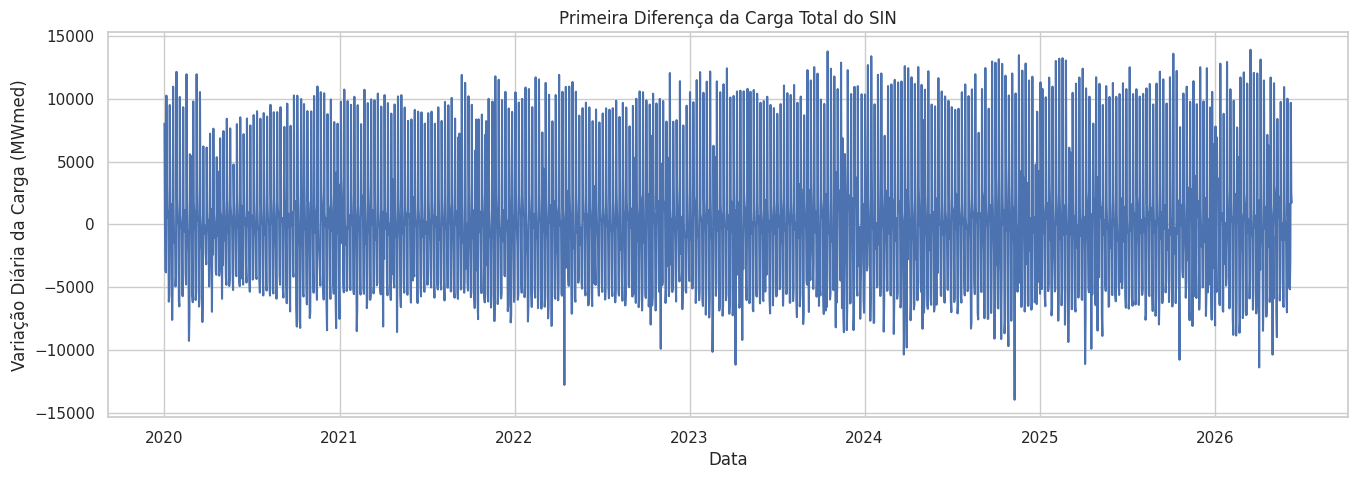

In [ ]:
# CÉLULA 33 - GRÁFICO DA SÉRIE DIFERENCIADA

plt.figure(figsize=(16,5))

plt.plot(
    sin["din_instante"],
    sin["diff1"]
)

plt.title("Primeira Diferença da Carga Total do SIN")
plt.xlabel("Data")
plt.ylabel("Variação Diária da Carga (MWmed)")

plt.show()

In [ ]:
# CÉLULA 34 - TESTE ADF APÓS DIFERENCIAÇÃO

serie_diff = sin["diff1"].dropna()

resultado_adf_diff = adfuller(serie_diff)

print("ADF:", resultado_adf_diff[0])
print("p-value:", resultado_adf_diff[1])

if resultado_adf_diff[1] < 0.05:
    print("Interpretação: a série diferenciada pode ser considerada estacionária.")
else:
    print("Interpretação: a série diferenciada ainda não é estacionária.")

ADF: -10.803306624068934
p-value: 1.9922485757361382e-19
Interpretação: a série diferenciada pode ser considerada estacionária.


<Figure size 1400x500 with 0 Axes>

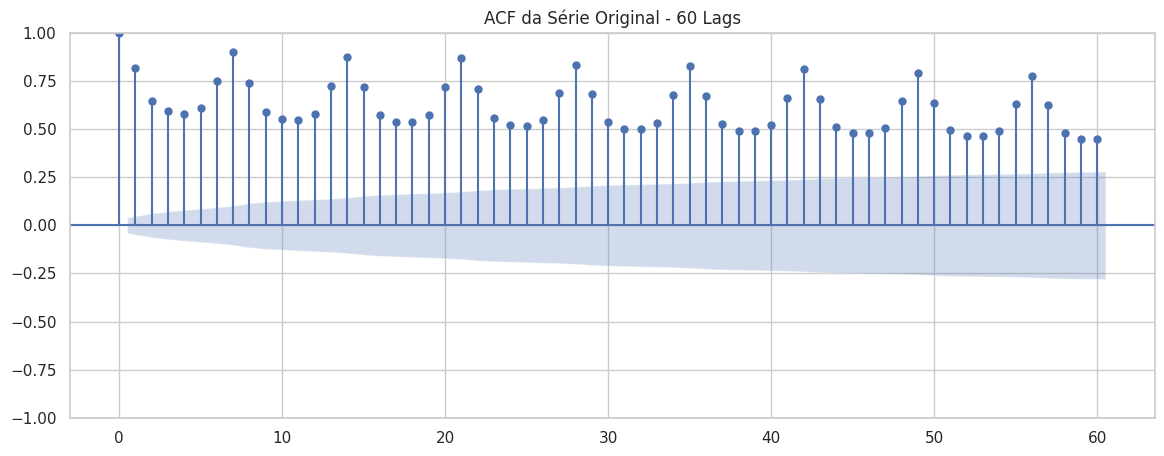

In [ ]:
# CÉLULA 35 - AUTOCORRELAÇÃO COM 60 LAGS

plt.figure(figsize=(14,5))

plot_acf(
    sin["val_cargaenergiamwmed"],
    lags=60
)

plt.title("ACF da Série Original - 60 Lags")

plt.show()

<Figure size 1400x500 with 0 Axes>

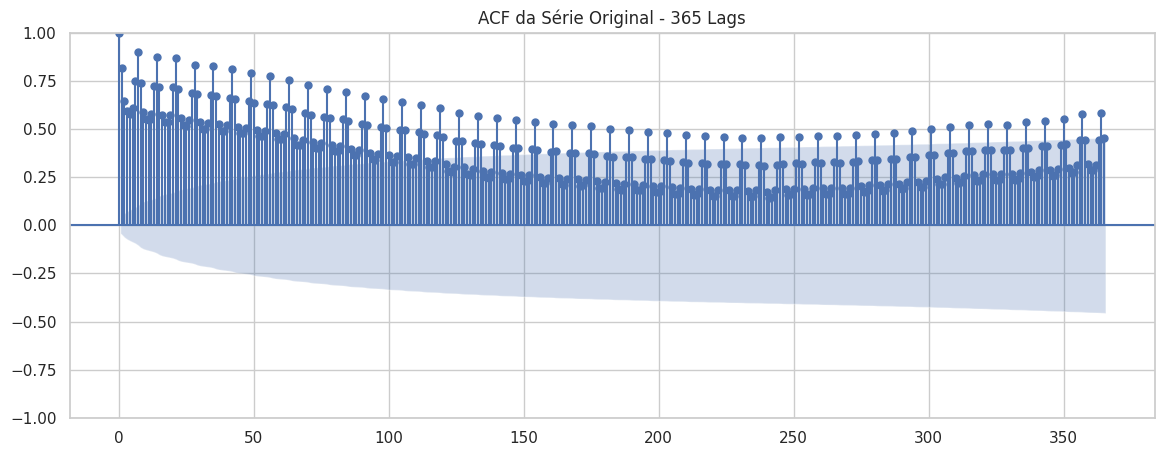

In [ ]:
# CÉLULA 36 - AUTOCORRELAÇÃO COM 365 LAGS

plt.figure(figsize=(14,5))

plot_acf(
    sin["val_cargaenergiamwmed"],
    lags=365
)

plt.title("ACF da Série Original - 365 Lags")

plt.show()

<Figure size 1400x500 with 0 Axes>

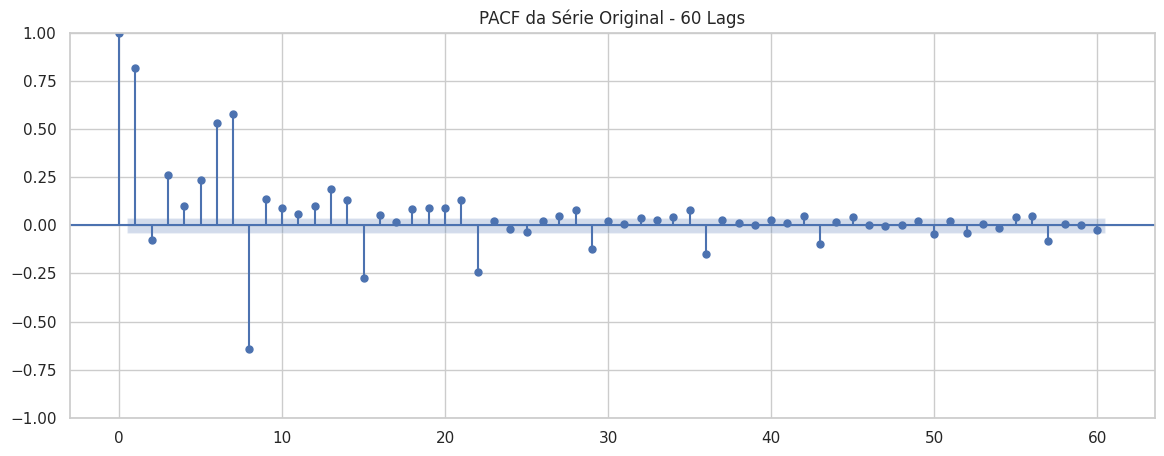

In [ ]:
# CÉLULA 37 - PACF COM 60 LAGS

plt.figure(figsize=(14,5))

plot_pacf(
    sin["val_cargaenergiamwmed"],
    lags=60,
    method="ywm"
)

plt.title("PACF da Série Original - 60 Lags")

plt.show()

<Figure size 1400x500 with 0 Axes>

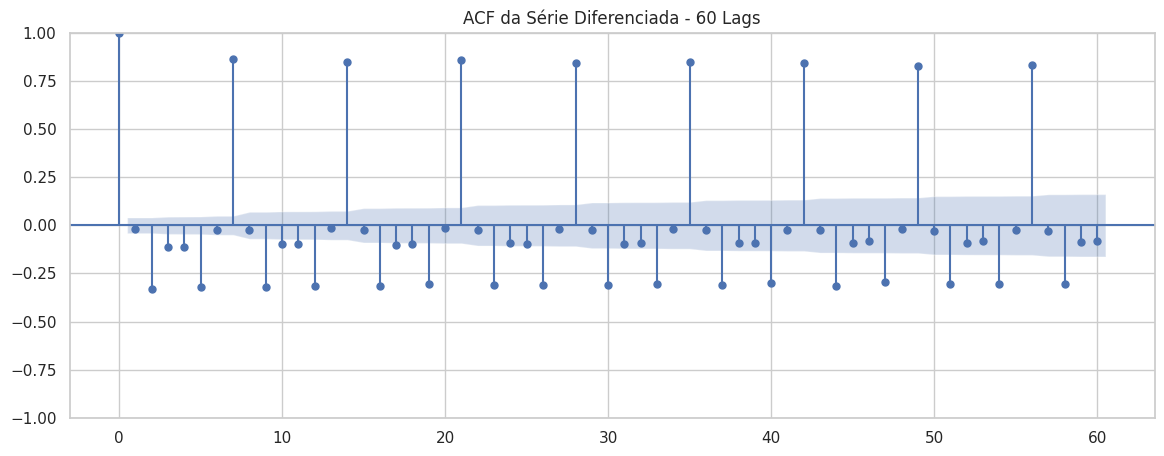

In [ ]:
# CÉLULA 38 - ACF DA SÉRIE DIFERENCIADA

plt.figure(figsize=(14,5))

plot_acf(
    serie_diff,
    lags=60
)

plt.title("ACF da Série Diferenciada - 60 Lags")

plt.show()

<Figure size 1400x500 with 0 Axes>

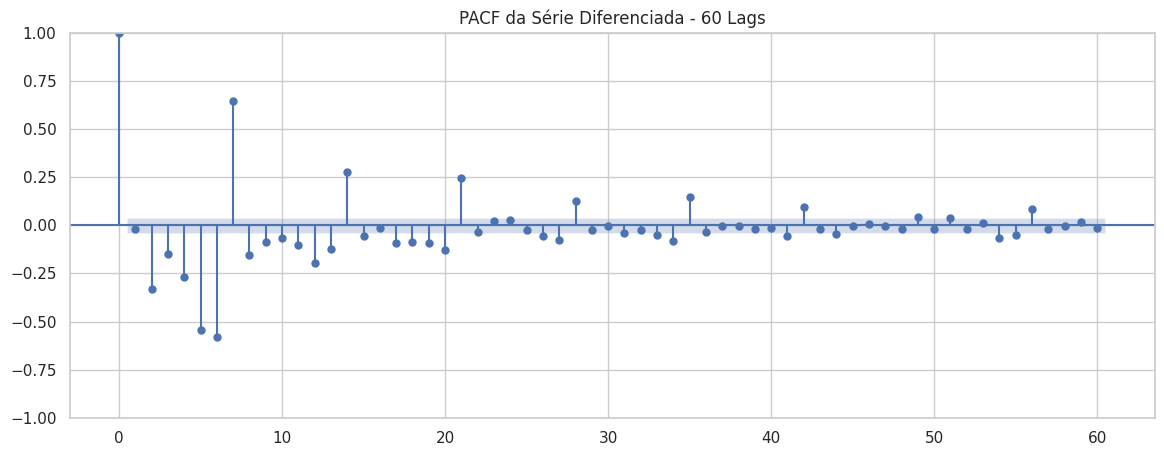

In [ ]:
# CÉLULA 39 - PACF DA SÉRIE DIFERENCIADA

plt.figure(figsize=(14,5))

plot_pacf(
    serie_diff,
    lags=60,
    method="ywm"
)

plt.title("PACF da Série Diferenciada - 60 Lags")

plt.show()

In [ ]:
# CÉLULA 40 - CRIAÇÃO DE FEATURES TEMPORAIS

sin["dia"] = sin["din_instante"].dt.day
sin["semana_ano"] = sin["din_instante"].dt.isocalendar().week.astype(int)
sin["trimestre"] = sin["din_instante"].dt.quarter

sin["mes_sin"] = np.sin(2 * np.pi * sin["mes"] / 12)
sin["mes_cos"] = np.cos(2 * np.pi * sin["mes"] / 12)

sin["fim_de_semana"] = sin["dia_semana_num"].isin([5, 6]).astype(int)

# Lags temporais

sin["lag_1"] = (sin["val_cargaenergiamwmed"].shift(1))
sin["lag_7"] = (sin["val_cargaenergiamwmed"].shift(7))
sin["lag_14"] = (sin["val_cargaenergiamwmed"].shift(14))
sin["lag_30"] = (sin["val_cargaenergiamwmed"].shift(30))

sin.head()

,din_instante,val_cargaenergiamwmed,ma30,ma90,ano,mes,dia_semana_num,dia_semana,diff1,dia,semana_ano,trimestre,mes_sin,mes_cos,fim_de_semana,lag_1,lag_7,lag_14,lag_30
0,2020-01-01,57135.105146,NaN,NaN,2020,1,2,Quarta,NaN,1,1,1,0.5,0.866025,0,NaN,NaN,NaN,NaN
1,2020-01-02,65163.694208,NaN,NaN,2020,1,3,Quinta,8028.589063,2,1,1,0.5,0.866025,0,57135.105146,NaN,NaN,NaN
2,2020-01-03,65150.402708,NaN,NaN,2020,1,4,Sexta,-13.291500,3,1,1,0.5,0.866025,0,65163.694208,NaN,NaN,NaN
3,2020-01-04,61463.301375,NaN,NaN,2020,1,5,Sábado,-3687.101333,4,1,1,0.5,0.866025,1,65150.402708,NaN,NaN,NaN
4,2020-01-05,57634.677208,NaN,NaN,2020,1,6,Domingo,-3828.624167,5,1,1,0.5,0.866025,1,61463.301375,NaN,NaN,NaN


In [ ]:
# CÉLULA 41 - COMPARAÇÃO ENTRE DIAS ÚTEIS E FINAIS DE SEMANA

media_fim_semana = (
    sin.groupby("fim_de_semana")["val_cargaenergiamwmed"]
       .mean()
       .reset_index()
)

media_fim_semana["tipo_dia"] = media_fim_semana["fim_de_semana"].map({
    0: "Dia útil",
    1: "Final de semana"
})

media_fim_semana

,fim_de_semana,val_cargaenergiamwmed,tipo_dia
0,0,75213.395955,Dia útil
1,1,66785.074332,Final de semana


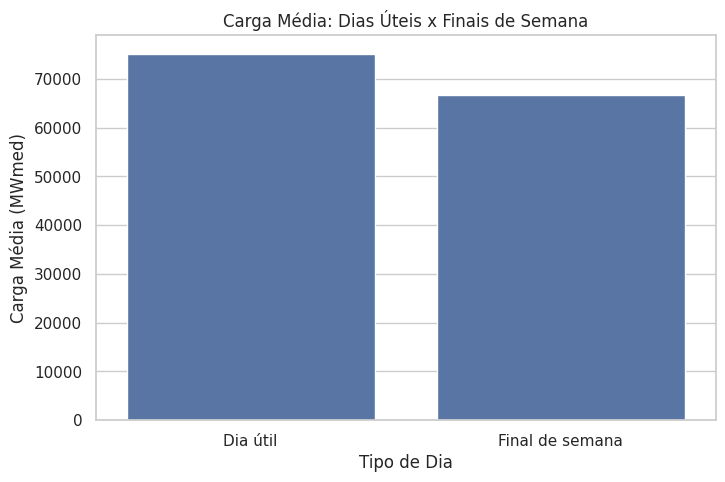

In [ ]:
# CÉLULA 42 - GRÁFICO DIAS ÚTEIS X FINAIS DE SEMANA

plt.figure(figsize=(8,5))

sns.barplot(
    data=media_fim_semana,
    x="tipo_dia",
    y="val_cargaenergiamwmed"
)

plt.title("Carga Média: Dias Úteis x Finais de Semana")
plt.xlabel("Tipo de Dia")
plt.ylabel("Carga Média (MWmed)")

plt.show()

In [ ]:
# CÉLULA 43 - CONCLUSÕES AUTOMÁTICAS DO EDA

print("Resumo do EDA")
print("-" * 50)

print(f"Período analisado: {sin['din_instante'].min().date()} até {sin['din_instante'].max().date()}")
print(f"Total de dias na série agregada: {len(sin)}")
print(f"Datas faltantes: {len(datas_faltantes)}")
print(f"Carga média do SIN: {sin['val_cargaenergiamwmed'].mean():.2f} MWmed")
print(f"Carga mínima do SIN: {sin['val_cargaenergiamwmed'].min():.2f} MWmed")
print(f"Carga máxima do SIN: {sin['val_cargaenergiamwmed'].max():.2f} MWmed")
print(f"Quantidade de outliers encontrados: {len(outliers)}")
print(f"p-value ADF série original: {resultado_adf[1]:.4f}")
print(f"p-value ADF série diferenciada: {resultado_adf_diff[1]:.2e}")

print("\nInterpretação geral:")
print("A série de carga total do SIN apresenta comportamento temporal com tendência, sazonalidade e dependência entre observações.")
print("O teste ADF na série original indica se ela é estacionária ou não.")
print("A diferenciação é uma transformação importante para preparar a série para modelos estatísticos como ARIMA e SARIMA.")
print("As análises por mês e por dia da semana indicam que variáveis de calendário podem ser úteis em modelos de previsão.")

Resumo do EDA
--------------------------------------------------
Período analisado: 2020-01-01 até 2026-06-10
Total de dias na série agregada: 2353
Datas faltantes: 0
Carga média do SIN: 72806.33 MWmed
Carga mínima do SIN: 48600.94 MWmed
Carga máxima do SIN: 95880.76 MWmed
Quantidade de outliers encontrados: 6
p-value ADF série original: 0.2598
p-value ADF série diferenciada: 1.99e-19

Interpretação geral:
A série de carga total do SIN apresenta comportamento temporal com tendência, sazonalidade e dependência entre observações.
O teste ADF na série original indica se ela é estacionária ou não.
A diferenciação é uma transformação importante para preparar a série para modelos estatísticos como ARIMA e SARIMA.
As análises por mês e por dia da semana indicam que variáveis de calendário podem ser úteis em modelos de previsão.


In [ ]:
# CÉLULA 44 - BASE FINAL PARA MODELAGEM

base_modelagem = sin[[
    "din_instante",
    "val_cargaenergiamwmed",
    "ano",
    "mes",
    "dia",
    "dia_semana_num",
    "semana_ano",
    "trimestre",
    "fim_de_semana",
    "ma30",
    "ma90",
    "mes_sin",
    "mes_cos",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "diff1"
]].copy()

# As médias móveis e a diferenciação geram valores nulos nas primeiras observações da série.
# Como esses registros não poderão ser utilizados em modelos preditivos, eles são removidos nesta etapa.

base_modelagem = (
    base_modelagem
    .dropna()
    .reset_index(drop=True)
)

base_modelagem.head()

,din_instante,val_cargaenergiamwmed,ano,mes,dia,dia_semana_num,semana_ano,trimestre,fim_de_semana,ma30,ma90,mes_sin,mes_cos,lag_1,lag_7,lag_14,lag_30,diff1
0,2020-03-30,61869.405625,2020,3,30,0,14,1,0,66321.431064,67883.616208,1.000000,6.123234e-17,55748.927417,62885.028292,72797.026208,63551.443625,6120.478208
1,2020-03-31,62858.071167,2020,3,31,1,14,1,0,66505.199554,67947.204719,1.000000,6.123234e-17,61869.405625,62120.796167,73601.772417,57345.016458,988.665542
2,2020-04-01,62597.975375,2020,4,1,2,14,2,0,66353.635144,67918.696732,0.866025,-5.000000e-01,62858.071167,61676.421083,73496.042208,67144.907667,-260.095792
3,2020-04-02,62945.854958,2020,4,2,3,14,2,0,66155.598078,67894.201757,0.866025,-5.000000e-01,62597.975375,61582.438375,72084.710583,68886.966958,347.879583
4,2020-04-03,62041.437000,2020,4,3,4,14,2,0,65893.147365,67900.625486,0.866025,-5.000000e-01,62945.854958,61379.396583,70002.267000,69914.958375,-904.417958


# Modelos

## Análise dos Resultados, Limitações e Conclusões

## Objetivo da Modelagem

Após a etapa de Análise Exploratória dos Dados (EDA), foram avaliadas diferentes abordagens de previsão com o objetivo de estimar a carga diária do Sistema Interligado Nacional (SIN).

Foram considerados:

* Baseline Semanal (modelo de referência);
* Holt-Winters (modelo clássico);
* Prophet (modelo moderno para séries temporais);
* XGBoost (modelo moderno baseado em Machine Learning).

A avaliação foi realizada utilizando os últimos 365 dias da série como conjunto de teste.

---

## Principais Resultados

### Divisão Temporal

A separação dos dados respeitou a ordem cronológica da série.

Em séries temporais não é permitido embaralhar as observações, pois isso causaria vazamento de informações do futuro para o passado.

Dessa forma:

* Treino → observações mais antigas;
* Teste → observações mais recentes.

Essa estratégia reproduz um cenário real de previsão.

---

### Baseline Semanal

O modelo Baseline Semanal apresentou:

**MAPE ≈ 3,46%**

A estratégia utilizada consiste em prever a carga de um dia utilizando o valor observado exatamente sete dias antes.

Mesmo sendo extremamente simples, o modelo apresentou desempenho superior a alguns modelos mais sofisticados.

Esse resultado confirma as evidências encontradas durante o EDA, especialmente a forte sazonalidade semanal observada na análise por dia da semana e nos gráficos de autocorrelação.

---

### Holt-Winters

O modelo Holt-Winters apresentou:

**MAPE ≈ 7,60%**

O modelo conseguiu capturar adequadamente:

* Tendência;
* Nível;
* Sazonalidade semanal.

Entretanto, apresentou desempenho inferior aos demais modelos avaliados, sugerindo que a série possui relações temporais mais complexas do que aquelas representadas apenas pelos componentes clássicos de suavização exponencial.

---

### Prophet

O modelo Prophet apresentou:

**MAPE ≈ 4,08%**

Os resultados indicam que o modelo conseguiu capturar automaticamente:

* Tendência de longo prazo;
* Sazonalidade semanal;
* Sazonalidade anual.

O desempenho obtido demonstra que a série apresenta padrões estruturados e previsíveis.

---

### XGBoost

O modelo XGBoost apresentou:

**MAPE ≈ 1,78%**

Foi o melhor resultado entre todos os modelos avaliados.

O ganho de desempenho ocorreu após a utilização de variáveis temporais derivadas da própria série, principalmente:

* lag_1;
* lag_7;
* lag_14;
* lag_30.

Essas variáveis representam observações passadas da carga elétrica e permitiram ao modelo capturar de forma mais eficiente a dependência temporal presente nos dados.

O resultado demonstra que o histórico recente da série possui elevado poder preditivo.

---

## Comparação dos Modelos

| Modelo           | MAPE (%) |
| ---------------- | -------: |
| XGBoost          |     1,78 |
| Baseline Semanal |     3,46 |
| Prophet          |     4,08 |
| Holt-Winters     |     7,60 |

O XGBoost apresentou o melhor desempenho geral.

Entretanto, o excelente resultado do Baseline Semanal merece destaque, pois demonstra que a sazonalidade semanal é um dos componentes mais importantes da série.

---

## Relação entre EDA e Modelagem

Os resultados obtidos validam diversas descobertas realizadas durante a etapa exploratória.

| Descoberta no EDA                   | Impacto na Modelagem                       |
| ----------------------------------- | ------------------------------------------ |
| Sazonalidade semanal                | Baseline competitivo                       |
| Picos na ACF em múltiplos de 7 dias | Criação dos lags                           |
| Tendência crescente                 | Prophet e Holt-Winters                     |
| Dependência temporal                | Melhor desempenho do XGBoost               |
| Não estacionariedade                | Justificativa para transformações da série |

Isso demonstra que a etapa de EDA foi fundamental para orientar as decisões tomadas durante a construção dos modelos.

---

## Limitações do Projeto

Apesar dos resultados satisfatórios, algumas limitações devem ser consideradas.

### Variáveis Utilizadas

A modelagem foi realizada principalmente utilizando informações históricas da própria carga elétrica e variáveis derivadas da data.

Mesmo sem variáveis externas, os modelos apresentaram excelente desempenho, especialmente o XGBoost.

Entretanto, fatores como temperatura, precipitação, feriados e indicadores econômicos também influenciam o consumo de energia elétrica e poderiam ser avaliados em estudos futuros.

### Mudanças Metodológicas da Série

De acordo com a documentação do ONS, a forma de cálculo da carga sofreu alterações ao longo do período analisado.

Entre elas destacam-se:

* Inclusão da geração de usinas não despachadas a partir de 2021;
* Inclusão da estimativa de Micro e Minigeração Distribuída (MMGD) a partir de 2023.

Essas mudanças podem introduzir pequenas alterações estruturais na série ao longo do tempo.

### Horizonte de Avaliação

Os resultados foram obtidos utilizando os últimos 365 dias como conjunto de teste.

Embora essa abordagem represente um cenário realista de previsão, diferentes horizontes de avaliação podem produzir resultados distintos.

---

## Trabalhos Futuros

Como continuidade deste estudo, podem ser exploradas as seguintes possibilidades:

* Inclusão de variáveis meteorológicas;
* Inclusão de feriados nacionais e regionais;
* Avaliação de outros algoritmos de Machine Learning, como LightGBM e CatBoost;
* Aplicação de redes neurais para séries temporais, como LSTM e Transformers;
* Realização de previsões individualizadas para cada subsistema do SIN;
* Avaliação de diferentes horizontes de previsão.

---

## Conclusão Final

Os resultados demonstraram que a carga elétrica diária do Sistema Interligado Nacional (SIN) apresenta forte previsibilidade, especialmente devido à sua sazonalidade semanal e elevada dependência temporal.

Entre os modelos avaliados, o XGBoost apresentou o melhor desempenho, alcançando MAPE de aproximadamente 1,78%.

Além disso, o excelente desempenho do Baseline Semanal reforça a importância dos padrões semanais identificados durante o EDA.

Dessa forma, os objetivos do projeto foram alcançados, contemplando todas as etapas propostas: preparação dos dados, análise exploratória, avaliação da estacionariedade, modelagem, comparação de métricas e previsão da carga elétrica do SIN.


In [ ]:
# CÉLULA 45 - PREPARAÇÃO DA SÉRIE TEMPORAL

serie = sin_ts["val_cargaenergiamwmed"]

print("Observações:", len(serie))

Observações: 2353


In [ ]:
# CÉLULA 46 - DIVISÃO TREINO E TESTE

horizonte_teste = 365

train = serie[:-horizonte_teste]
test = serie[-horizonte_teste:]

print("Treino:", len(train))
print("Teste:", len(test))

Treino: 1988
Teste: 365


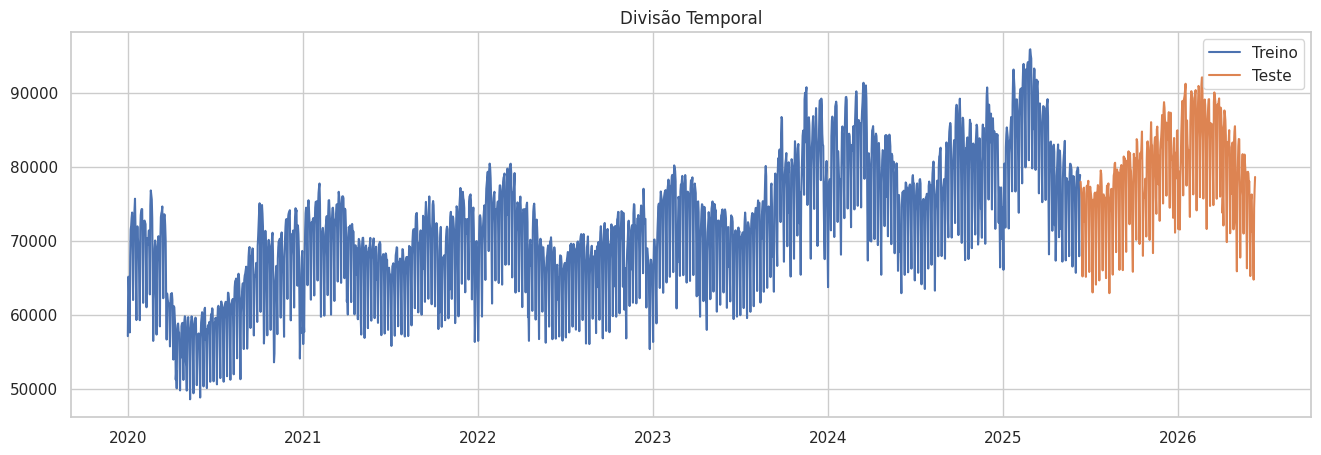

In [ ]:
# CÉLULA 47 - VISUALIZAÇÃO TREINO/TESTE

plt.figure(figsize=(16,5))

plt.plot(train, label="Treino")
plt.plot(test, label="Teste")

plt.title("Divisão Temporal")
plt.legend()

plt.show()

In [ ]:
# CÉLULA 48 - BASELINE SEMANAL

# Utiliza o valor observado exatamente 7 dias antes.

baseline_pred = serie.shift(7).iloc[-horizonte_teste:]

In [ ]:
# CÉLULA 49 - FUNÇÃO DE AVALIAÇÃO

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

resultados = []

def avaliar_modelo(nome, y_real, y_pred):

    mae = mean_absolute_error(y_real, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_real, y_pred)
    )

    mape = (
        mean_absolute_percentage_error(
            y_real,
            y_pred
        ) * 100
    )

    resultados.append(
        [nome, mae, rmse, mape]
    )

    print(f"\nModelo: {nome}")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

In [ ]:
# CÉLULA 50 - BASELINE

avaliar_modelo(
    "Baseline Semanal",
    test,
    baseline_pred
)


Modelo: Baseline Semanal
MAE : 2739.40
RMSE: 3643.66
MAPE: 3.46%


In [ ]:
# CÉLULA 51 - HOLT-WINTERS

from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=7
)

hw_fit = hw_model.fit()

hw_pred = hw_fit.forecast(
    len(test)
)

avaliar_modelo(
    "Holt-Winters",
    test,
    hw_pred
)


Modelo: Holt-Winters
MAE : 6221.52
RMSE: 7631.09
MAPE: 7.60%


In [ ]:
# CÉLULA 52 - PROPHET

from prophet import Prophet

prophet_train = train.reset_index()

prophet_train.columns = [
    "ds",
    "y"
]

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True
)

prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(
    periods=len(test),
    freq="D"
)

forecast = prophet_model.predict(future)

prophet_pred = (
    forecast["yhat"]
    .tail(len(test))
    .values
)

avaliar_modelo(
    "Prophet",
    test,
    prophet_pred
)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



Modelo: Prophet
MAE : 3135.92
RMSE: 3846.25
MAPE: 4.08%


In [ ]:
# CÉLULA 53 - PREPARAÇÃO DA BASE PARA XGBOOST

# O XGBoost utilizará as features criadas durante o EDA.

base_xgb = base_modelagem.copy()

base_xgb = base_xgb.dropna()

X = base_xgb.drop(
    columns=[
        "din_instante",
        "val_cargaenergiamwmed",
        "diff1",
        "ma30",
        "ma90"
    ]
)

y = base_xgb["val_cargaenergiamwmed"]

X_train = X.iloc[:-365]
X_test = X.iloc[-365:]

y_train = y.iloc[:-365]
y_test = y.iloc[-365:]

print(X_train.shape)
print(X_test.shape)

(1899, 13)
(365, 13)


In [ ]:
# CÉLULA 54 - TREINAMENTO XGBOOST

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

In [ ]:
# CÉLULA 55 - AVALIAÇÃO XGBOOST

avaliar_modelo(
    "XGBoost",
    y_test,
    xgb_pred
)


Modelo: XGBoost
MAE : 1402.59
RMSE: 2019.36
MAPE: 1.78%


In [ ]:
# CÉLULA 56 - COMPARAÇÃO DOS MODELOS

resultado_df = pd.DataFrame(
    resultados,
    columns=[
        "Modelo",
        "MAE",
        "RMSE",
        "MAPE (%)"
    ]
)

resultado_df = resultado_df.sort_values(
    "MAPE (%)"
)

resultado_df

,Modelo,MAE,RMSE,MAPE (%)
3,XGBoost,1402.586004,2019.364479,1.784783
0,Baseline Semanal,2739.400306,3643.658863,3.455073
2,Prophet,3135.918145,3846.254149,4.078281
1,Holt-Winters,6221.522991,7631.085678,7.602997


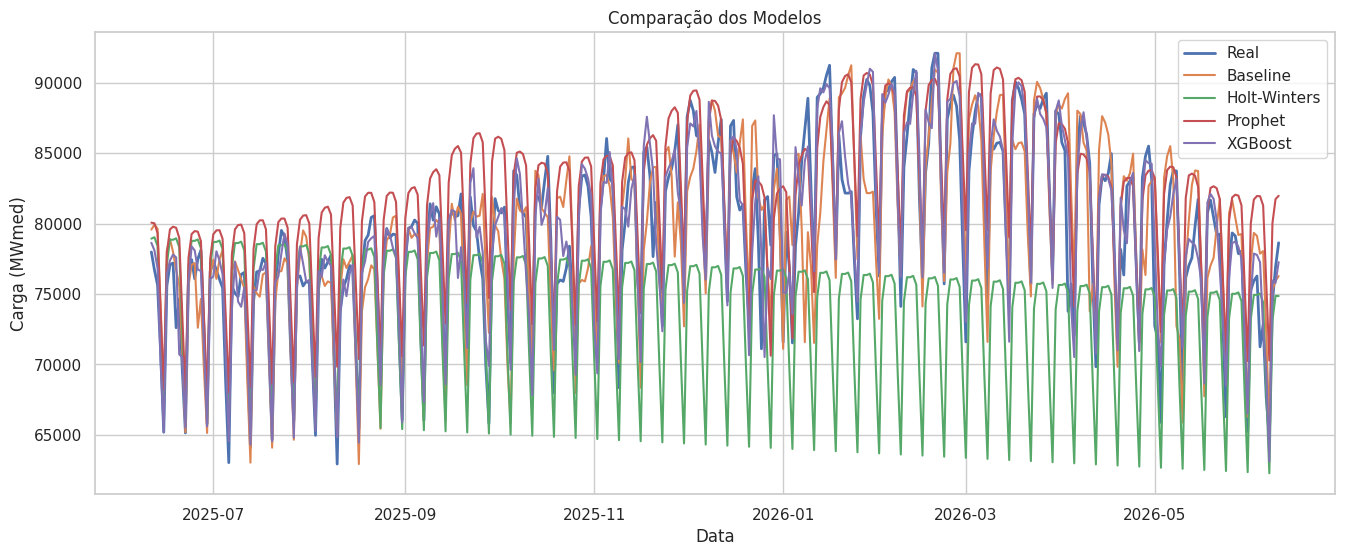

In [ ]:
# CÉLULA 57 - VISUALIZAÇÃO DAS PREVISÕES

datas_xgb_test = base_xgb["din_instante"].iloc[-365:]

plt.figure(figsize=(16,6))

plt.plot(
    test.index,
    test,
    label="Real",
    linewidth=2
)

plt.plot(
    test.index,
    baseline_pred,
    label="Baseline"
)

plt.plot(
    test.index,
    hw_pred,
    label="Holt-Winters"
)

plt.plot(
    test.index,
    prophet_pred,
    label="Prophet"
)

plt.plot(
    datas_xgb_test,
    xgb_pred,
    label="XGBoost"
)

plt.legend()
plt.title("Comparação dos Modelos")
plt.xlabel("Data")
plt.ylabel("Carga (MWmed)")

plt.show()

In [ ]:
# CÉLULA 58 - CONCLUSÃO AUTOMÁTICA

melhor = resultado_df.iloc[0]

print("Melhor modelo encontrado:")
print(melhor["Modelo"])

print("\nMAPE:")
print(f"{melhor['MAPE (%)']:.2f}%")

print("\nRanking final:")
display(resultado_df)

Melhor modelo encontrado:
XGBoost

MAPE:
1.78%

Ranking final:


,Modelo,MAE,RMSE,MAPE (%)
3,XGBoost,1402.586004,2019.364479,1.784783
0,Baseline Semanal,2739.400306,3643.658863,3.455073
2,Prophet,3135.918145,3846.254149,4.078281
1,Holt-Winters,6221.522991,7631.085678,7.602997
